In [1]:
pip install mediapipe opencv-python pandas scikit-learn tensorflow

In [2]:
from zipfile import ZipFile

In [3]:
with ZipFile('/content/Posturas.zip', 'r') as zip_ref:
    zip_ref.extractall('Posturas')

In [4]:
import os
import cv2
import mediapipe as mp
from tqdm import tqdm
import pandas as pd

dataset = "/content/Posturas/Posturas"

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

dados = []
labels = []

for classe in os.listdir(dataset):
    pasta = os.path.join(dataset, classe)
    for img_name in tqdm(os.listdir(pasta), desc=f"Processando {classe}"):
        img_path = os.path.join(pasta, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = pose.process(img_rgb)

        if not results.pose_landmarks:
            continue

        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z])

        dados.append(keypoints)
        labels.append(classe)

pose.close()

df = pd.DataFrame(dados)
df['label'] = labels
df.to_csv('posturas_keypoints.csv', index=False)

print("Extração finalizada. CSV salvo em 'posturas_keypoints.csv'.")


Processando Levantado: 100%|██████████| 200/200 [00:12<00:00, 16.46it/s]


Extração finalizada. CSV salvo em 'posturas_keypoints.csv'.


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

def carregar_dados(caminho_csv):
    """Carrega o dataset do arquivo CSV."""
    return pd.read_csv(caminho_csv)

def preparar_dados(df, coluna_label='label'):
    """Separa os atributos (X) e os rótulos (y) e codifica os rótulos."""
    X = df.drop(coluna_label, axis=1).values
    y = df[coluna_label].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    return X, y_enc, le

def dividir_normalizar(X, y_enc, test_size=0.3, random_state=42):
    """Divide em treino e teste, e normaliza os dados."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state, stratify=y_enc
    )
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)
    return X_train_norm, X_test_norm, y_train, y_test, scaler

def treinar_mlp(X_train, y_train, hidden_layers=(100, 50), max_iter=500, random_state=42):
    """Treina o classificador MLP."""
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layers, max_iter=max_iter, random_state=random_state)
    mlp.fit(X_train, y_train)
    return mlp

def mostrar_metricas(y_true, y_pred, classes):
    """Exibe matriz de confusão e relatório de classificação."""
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))

    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=classes))


df = carregar_dados('posturas_keypoints.csv')
X, y_enc, label_encoder = preparar_dados(df)
X_train, X_test, y_train, y_test, scaler = dividir_normalizar(X, y_enc)
mlp_model = treinar_mlp(X_train, y_train)
y_pred = mlp_model.predict(X_test)

mostrar_metricas(y_test, y_pred, label_encoder.classes_)





Matriz de Confusão:
[[34  3  1]
 [ 4 36 11]
 [ 1  5 40]]

Relatório de Classificação:
              precision    recall  f1-score   support

     Deitado       0.87      0.89      0.88        38
   Levantado       0.82      0.71      0.76        51
     Sentado       0.77      0.87      0.82        46

    accuracy                           0.81       135
   macro avg       0.82      0.82      0.82       135
weighted avg       0.82      0.81      0.81       135



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

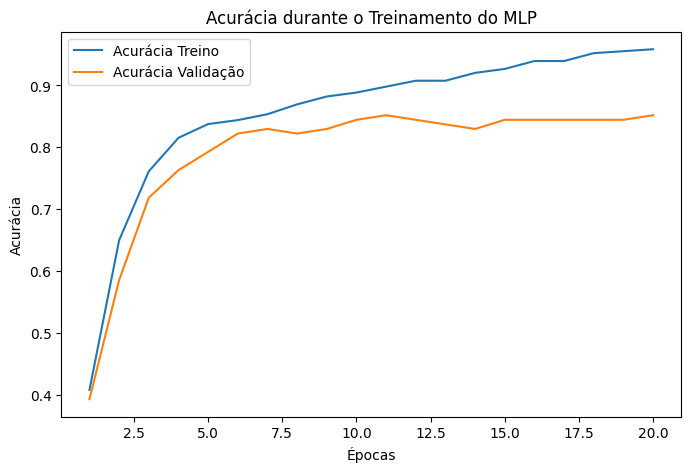

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1, warm_start=True, random_state=42)

epochs = 20
train_acc = []
val_acc = []

for i in range(epochs):
    mlp.fit(X_train, y_train)
    y_train_pred = mlp.predict(X_train)
    y_val_pred = mlp.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_test, y_val_pred))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_acc, label='Acurácia Treino')
plt.plot(range(1, epochs+1), val_acc, label='Acurácia Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Acurácia durante o Treinamento do MLP')
plt.legend()
plt.show()


In [11]:
joblib.dump({'modelo': mlp_model, 'scaler': scaler, 'label_encoder': label_encoder}, 'modelo_MLP.pkl')

['modelo_MLP.pkl']